# Import Lib's

In [20]:
-import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from keras import layers
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv('/content/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Preprocess text

In [3]:
import re
import html
import nltk # for natural language toolkit
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer # for reducing words to their root form

nltk.download('stopwords')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english')) # gets list of english stopwords & converts them into set.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
def clean_Review_with_stopwords_and_stemmer(review):
    # Removes html entites(#amp, &lt)
    review = html.unescape(review)
    # Removes all the puntuations.
    review = re.sub(r'[^\w\s]', '', review)
    review = review.lower()
    # Removes numbers and other non-alphabetic characters
    review = re.sub(r'[^a-z\s]', '', review)
    words = review.split()
    # Tokenization.
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]
    cleaned_review = ' '.join(cleaned_words)
    return cleaned_review

In [5]:
df['review'] = df['review'].apply(clean_Review_with_stopwords_and_stemmer)
df.head()

,review,sentiment
0,one review mention watch oz episod youll hook ...,positive
1,wonder littl product br br film techniqu unass...,positive
2,thought wonder way spend time hot summer weeke...,positive
3,basic there famili littl boy jake think there ...,negative
4,petter mattei love time money visual stun film...,positive


# Encoding

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])
df.head()

,review,sentiment
0,one review mention watch oz episod youll hook ...,1
1,wonder littl product br br film techniqu unass...,1
2,thought wonder way spend time hot summer weeke...,1
3,basic there famili littl boy jake think there ...,0
4,petter mattei love time money visual stun film...,1


# Model Splitting

In [14]:
x = df.drop('sentiment', axis= 1)
y = df['sentiment']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((40000, 1), (10000, 1))

In [15]:
# Tokenize to transform into seq of integer.
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train['review'])

x_train = tokenizer.texts_to_sequences(x_train['review']) # converts each 'review' into sequence of intergers.
x_test = tokenizer.texts_to_sequences(x_test['review'])

# Vocabolary size and max len of sequence is calculated.
vocab_size = len(tokenizer.word_index) + 1
max_len = max(len(x) for x in x_train)

# Ensure all sequnece have same length.
x_train = pad_sequences(x_train, padding='post', maxlen=max_len)
x_test = pad_sequences(x_test, padding='post', maxlen=max_len)
x_train

array([[101, 726, 367, ...,   0,   0,   0],
       [ 12, 262,   2, ...,   0,   0,   0],
       [448,  28,  14, ...,   0,   0,   0],
       ...,
       [573,   4, 279, ...,   0,   0,   0],
       [222,  97, 265, ...,   0,   0,   0],
       [470,   2, 194, ...,   0,   0,   0]], dtype=int32)

# Building CNN

In [18]:
# Note: When deailing with 'text' like data embedding layer is included.

embedding_dim = 50
model = Sequential()
model.add(layers.Embedding(vocab_size, embedding_dim, input_shape=(max_len,)))
model.add(layers.Conv1D(128, 5, activation= 'relu'))
model.add(layers.GlobalMaxPooling1D())

model.add(layers.Dense(64, activation= 'relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(32, activation= 'relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(1, activation= 'sigmoid')) # Sigmoid func is used for binary classf & text classf.

model.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics= ['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 1440, 50)       │     6,003,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1436, 128)      │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,045,497 (23.06 MB)

 Trainable params: 6,045,497 (23.06 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(x_train, y_train, epochs= 10, verbose= True, validation_data= (x_test, y_test))

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7220 - loss: 0.5067 - val_accuracy: 0.8903 - val_loss: 0.2704
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9351 - loss: 0.1836 - val_accuracy: 0.8897 - val_loss: 0.2677
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9856 - loss: 0.0518 - val_accuracy: 0.8710 - val_loss: 0.4207
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9932 - loss: 0.0218 - val_accuracy: 0.8826 - val_loss: 0.5064
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.8714 - val_loss: 0.6590
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9960 - loss: 0.0120 - val_accuracy: 0.8728 - val_loss: 0.6661
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9976 - loss: 0.0078 - val_accuracy: 0.8753 - val_loss: 0.7211
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9979 -

# Plotting Diff's

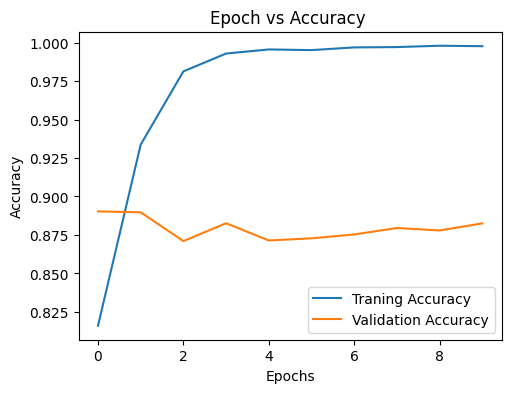

In [24]:
plt.figure(figsize= (12, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label= 'Traning Accuracy')
plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')
plt.title('Epoch vs Accuracy ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

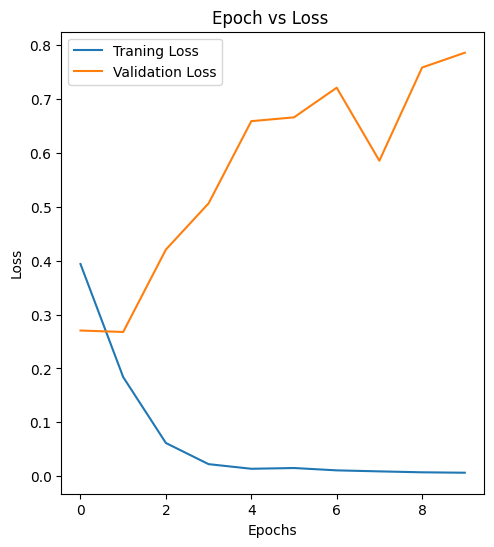

In [25]:
plt.figure(figsize= (12, 6))
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label= 'Traning Loss')
plt.plot(history.history['val_loss'], label= 'Validation Loss')
plt.title('Epoch vs Loss ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Classf Report

In [26]:
y_pred = (model.predict(x_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      4961
           1       0.90      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Confusion Matrix

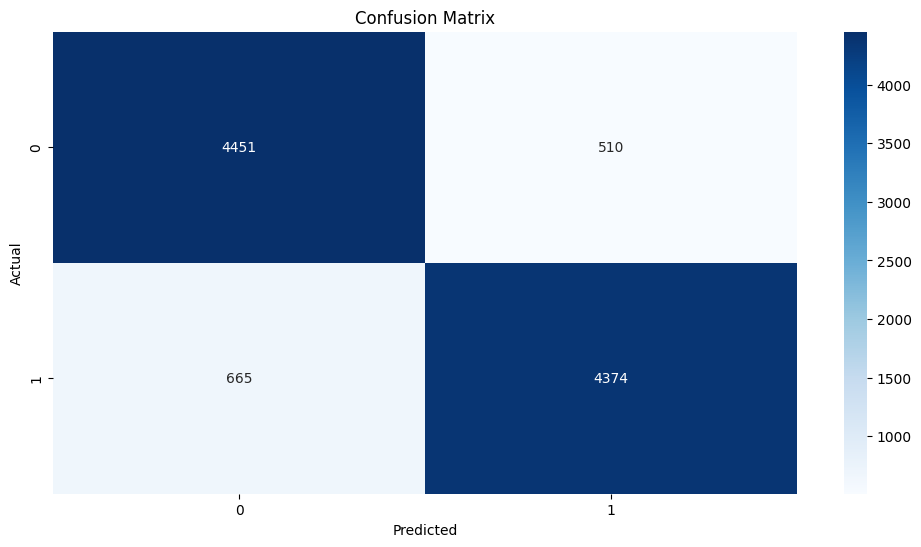

In [27]:
import seaborn as sns
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize= (12, 6))
sns.heatmap(conf_matrix, annot= True, cbar= True, fmt= 'd', cmap= 'Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Sentimental Func

In [30]:
def predict_sentiment(review):
    text = clean_Review_with_stopwords_and_stemmer(review)

    seq = tokenizer.texts_to_sequences([text])
    pad_seq = pad_sequences(seq, padding= 'post', maxlen= max_len)

    pred = model.predict(pad_seq)[0][0]

    if pred < 0.5:
        print('The movie review is: Negative!')
    else:
        print('The movie review is: Positive.')

In [31]:
# Test1
input_txt = 'The is just awful to watch'
predict_sentiment(input_txt)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
The movie review is: Negative!


# Model Saving

In [32]:
import pickle
model.save('sentiment_model.h5')
pickle.dump(tokenizer, open('tokenizer.pkl', 'wb'))